# LeafGuard — Plant Disease Classifier Model Development

**Owner:** Keshav Sarda  
**Project:** Portfolio Project for Data Science (Junior Associate) interview at Celebal Technologies

---

## 1. Project Goal & Design Decisions
The goal of this notebook is to train an image classification model to diagnose potato leaf conditions (Healthy vs. Early Blight vs. Late Blight) from photos.

### Why Transfer Learning?
- **Efficiency:** Training a Deep Convolutional Neural Network (CNN) from scratch requires large datasets (tens of thousands of images) and hours/days of GPU compute.
- **Pretrained Feature Extractors:** We leverage `MobileNetV2`, pretrained on over 1.4 million images from ImageNet. MobileNetV2 has learned robust low-level features (edges, textures, shapes) that generalize well to other domains like agriculture.
- **Mobile-Friendly Architecture:** MobileNetV2 is designed for lightweight and low-latency execution, making it perfect for rapid FastAPI API serving.

### Scoping Decision
- We scoped down the 38-class PlantVillage dataset to **Potato** (3 classes) and capped the class size to **200 images**. This prevents CPU training bottlenecks while demonstrating the full end-to-end data preparation, augmentation, and validation workflow.

## 2. Load Libraries & Setup Environment

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from keras import layers, models
from keras.applications import MobileNetV2
from keras.utils import image_dataset_from_directory

# Output directories config
DATA_DIR = "../data"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")
TEST_DIR = os.path.join(DATA_DIR, "test")
MODEL_PATH = "../models/plant_disease_model.keras"
EVAL_DIR = "../evaluation"

print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow Version: 2.20.0
Num GPUs Available: 0


## 3. Exploratory Data Analysis & Loading
We load our stratified images into TensorFlow datasets, which handle disk-to-tensor pipelines automatically. Images are loaded with shape `(224, 224)` with RGB colors.

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

val_dataset = image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

test_dataset = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = train_dataset.class_names
print("Class labels loaded:", class_names)

Found 386 files belonging to 3 classes.
Found 82 files belonging to 3 classes.
Found 84 files belonging to 3 classes.
Class labels loaded: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


### Visualizing Sample Leaves

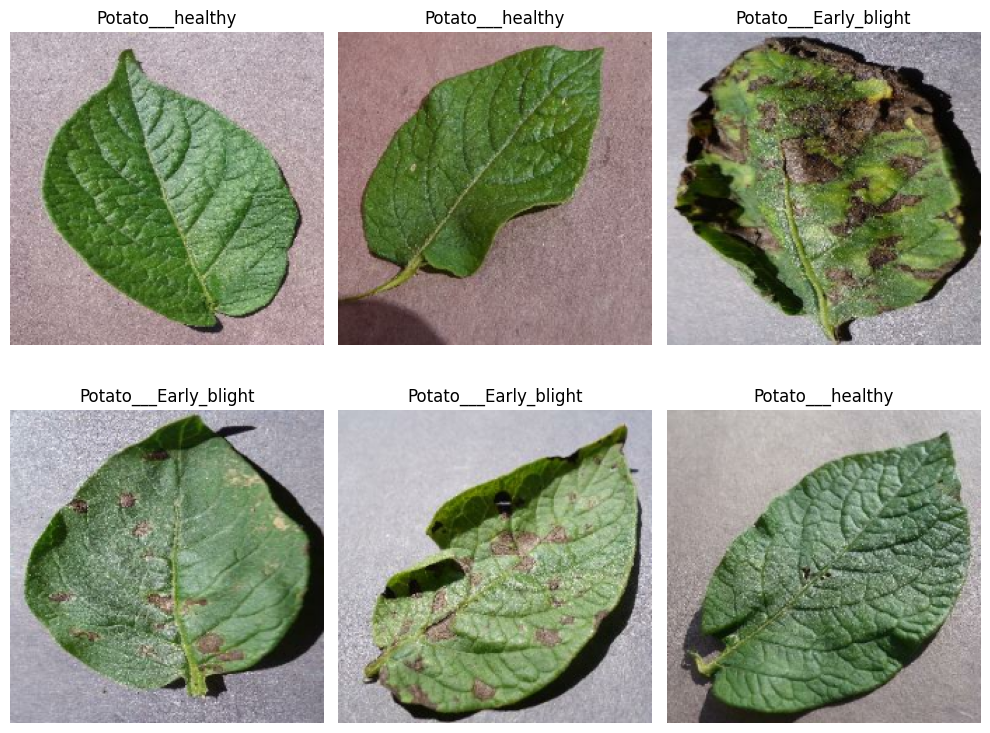

In [3]:
plt.figure(figsize=(10, 8))
for images, labels in train_dataset.take(1):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        class_idx = np.argmax(labels[i])
        plt.title(class_names[class_idx])
        plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Model Architecture & Data Augmentation
We construct our model pipeline using the functional API.
1. **Data Augmentation:** Flips, rotations, zoom, and brightness adjustments. This reduces overfitting because our dataset is small.
2. **Preprocessing:** Scales pixel values from `[0, 255]` to `[-1, 1]` for MobileNetV2.
3. **MobileNetV2 Backbone:** Extractor layers are frozen (`trainable = False`).
4. **Custom Classifier Head:** Dense layers mapping extraction vectors to our 3 output nodes (with Dropout regularization).

In [4]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1)
], name="data_augmentation")

# MobileNetV2 pre-processing layer
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

# Backbone
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
base_model.trainable = False

# Connect components
inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False) # training=False preserves BN stats
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Model Training

In [5]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.5868 - loss: 0.8464
Epoch 1: val_loss improved from None to 0.14889, saving model to ../models/plant_disease_model.keras

Epoch 1: finished saving model to ../models/plant_disease_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 779ms/step - accuracy: 0.7254 - loss: 0.5964 - val_accuracy: 0.9756 - val_loss: 0.1489
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.9015 - loss: 0.2334
Epoch 2: val_loss improved from 0.14889 to 0.11740, saving model to ../models/plant_disease_model.keras

Epoch 2: finished saving model to ../models/plant_disease_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 559ms/step - accuracy: 0.9067 - loss: 0.2472 - val_accuracy: 0.9634 - val_loss: 0.1174
Epoch 3/10
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.9423 - loss: 0.1379
Epoch 3: val_loss did not improve from 0.11740
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 521ms/step - accuracy: 0.9482 - loss: 0.1306 - val_accuracy: 0.9268 - val_loss: 0.1

## 6. Evaluation Curves

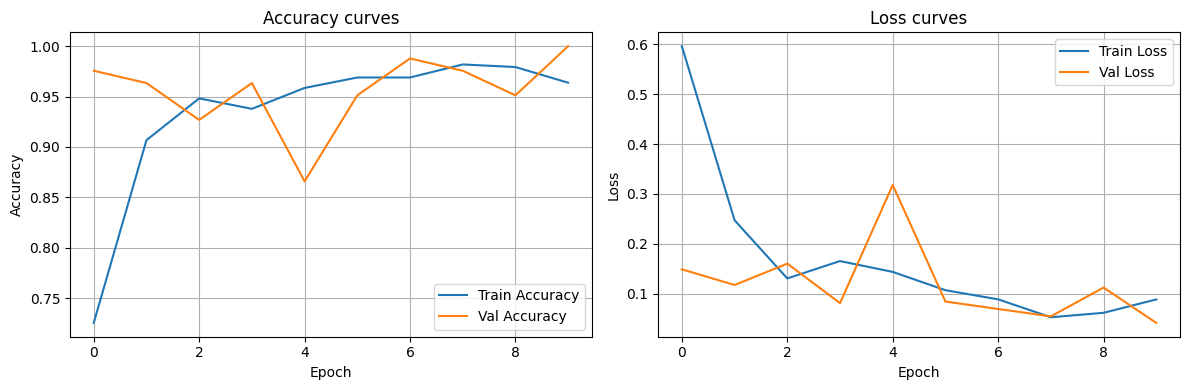

In [6]:
plt.figure(figsize=(12, 4))

# Accuracy Curves
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Curves
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 7. Metrics & Confusion Matrix on Held-Out Test Set

Classification Report:
                       precision    recall  f1-score   support

Potato___Early_blight       0.97      1.00      0.98        30
 Potato___Late_blight       0.97      0.97      0.97        30
     Potato___healthy       1.00      0.96      0.98        24

             accuracy                           0.98        84
            macro avg       0.98      0.98      0.98        84
         weighted avg       0.98      0.98      0.98        84



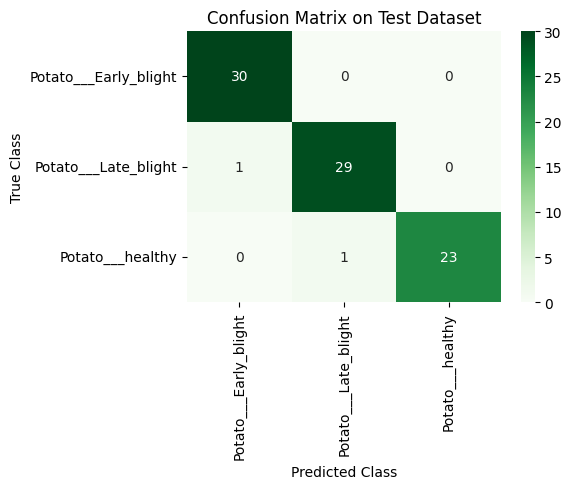

In [7]:
best_model = tf.keras.models.load_model(MODEL_PATH)

y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = best_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Greens', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix on Test Dataset')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()